In [4]:
from google.colab import drive

In [5]:
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df=pd.read_csv('/content/gdrive/MyDrive/T5/Dataset/IMDB Dataset.csv')

In [9]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [10]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [11]:
map_sentiment={'positive':1,'negative':0}

In [12]:
df['sentiment']=df['sentiment'].map(map_sentiment)

In [14]:
df.shape

(50000, 2)

## Text Preprossing
### Convert Text into lower and remove html tags,punctuations

In [15]:
df['review']=df['review'].str.lower()

In [16]:
import re
def remove_html(review):
    return re.sub(r'<.*?>', '', review)

In [17]:
df['review']=df['review'].apply(remove_html)

In [18]:
import string

def remove_punctuation(text):
    # Create a translation table to remove punctuation
    translation_table = str.maketrans('', '', string.punctuation)

    # Use the translate method to remove punctuation
    return text.translate(translation_table)


In [19]:
df['review']=df['review'].apply(remove_punctuation)

In [20]:
df['review']

,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production the filming tech...
2,i thought this was a wonderful way to spend ti...
3,basically theres a family where a little boy j...
4,petter matteis love in the time of money is a ...
...,...
49995,i thought this movie did a down right good job...
49996,bad plot bad dialogue bad acting idiotic direc...
49997,i am a catholic taught in parochial elementary...
49998,im going to have to disagree with the previous...


## Tokenization

In [21]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer

In [22]:
tokenizer=Tokenizer(oov_token='<nothing>')

In [23]:
tokenizer.fit_on_texts(df['review'])

In [24]:
len(tokenizer.word_index)

223805

In [25]:
sequences=tokenizer.texts_to_sequences(list(df['review']))

In [26]:
max_len=max([len(item) for item in sequences])

## Padding Sequences

In [27]:
from tensorflow.keras.utils import pad_sequences

In [28]:
padded_input_sequences=pad_sequences(sequences,maxlen=max_len,padding='pre')

In [29]:
padded_input_sequences.shape

(50000, 2450)

In [30]:
padded_input_sequences

array([[    0,     0,     0, ...,   122,  3988,   502],
       [    0,     0,     0, ...,  1890,    73,   223],
       [    0,     0,     0, ...,    64,    15,   331],
       ...,
       [    0,     0,     0, ..., 22953,     3,  5957],
       [    0,     0,     0, ...,    68,   708,    42],
       [    0,     0,     0, ...,   840,    11,    17]], dtype=int32)

### Spliting Data into training and testing


In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train,X_test,y_train,y_test=train_test_split(padded_input_sequences,df.sentiment,test_size=0.2,random_state=42)

In [33]:
X_train.shape

(40000, 2450)

## Model Building

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,GRU,SimpleRNN,Dropout,BatchNormalization,Embedding

In [39]:
model=Sequential()
model.add(Embedding(223805,250,input_length=2450))
model.add(LSTM(150,return_sequences=True))
model.add(LSTM(150))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [40]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [42]:
history=model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test))

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 236s 186ms/step - accuracy: 0.7340 - loss: 0.5186 - val_accuracy: 0.8900 - val_loss: 0.2806
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 232s 185ms/step - accuracy: 0.9309 - loss: 0.1889 - val_accuracy: 0.9084 - val_loss: 0.2362
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 232s 186ms/step - accuracy: 0.9803 - loss: 0.0675 - val_accuracy: 0.8808 - val_loss: 0.3773
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 232s 185ms/step - accuracy: 0.9938 - loss: 0.0214 - val_accuracy: 0.8947 - val_loss: 0.3534
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 232s 185ms/step - accuracy: 0.9975 - loss: 0.0106 - val_accuracy: 0.8938 - val_loss: 0.5562
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 232s 185ms/step - accuracy: 0.9990 - loss: 0.0039 - val_accuracy: 0.8838 - val_loss: 0.6241
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 232s 186ms/step - accuracy: 0.9990 - loss: 0.0032 - val_accuracy: 0.8866 - val_loss: 0.6367
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 232s 186ms/step - ac

Text(0.5, 0, 'epoch')

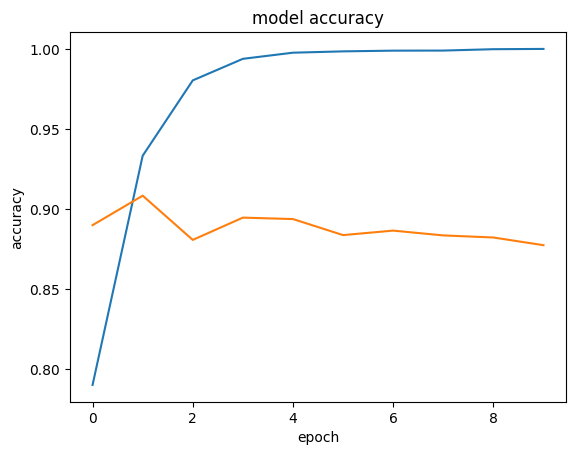

In [43]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

Text(0.5, 0, 'epoch')

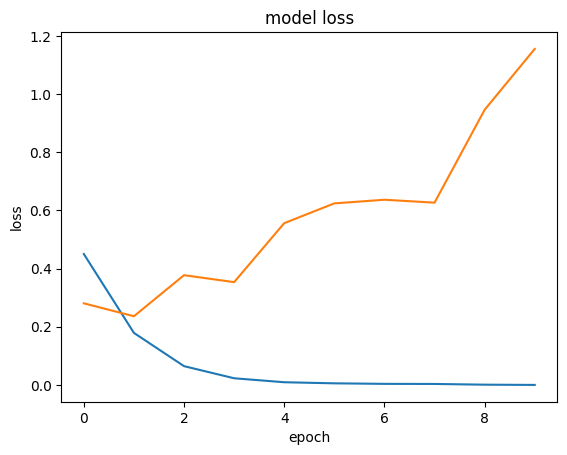

In [44]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

## Model Evaluation

In [45]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score

In [46]:
y_pred=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step


In [52]:
accuracy_score(y_test,y_pred.round())

0.8775

In [53]:
f1_score(y_test,y_pred.round())

0.8732802317161478

In [84]:
input='watch this movie'

In [85]:
tokenized_input=tokenizer.texts_to_sequences([input])

In [86]:
max_len

2450

In [87]:
padded_input=pad_sequences(tokenized_input,maxlen=max_len,padding='pre')

In [88]:
padded_input

array([[  0,   0,   0, ..., 103,  11,  17]], dtype=int32)

In [89]:
sentiment=model.predict(padded_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [90]:
np.round(sentiment)

array([[1.]], dtype=float32)